In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.widgets import RadioButtons, CheckButtons
import networkx as nx
import matplotlib.patches as mpatches
from collections import defaultdict

In [20]:
metabolites = pd.read_csv('data/metabolites.csv', index_col='metabolite_id')
reactions   = pd.read_csv('data/reactions.csv')

In [21]:
def buildMetabolicGraph(metabolites, reactions):
    
    G = nx.DiGraph()

    # Add metabolite nodes
    for metabolite_id, row in metabolites.iterrows():
        G.add_node(
            metabolite_id,
            name=row["name"],
            pathway=row["pathway"],
            formula=row["formula"]
        )

    # Add reaction edges
    for _, row in reactions.iterrows():
        G.add_edge(
            row["source"],
            row["target"],
            reaction_id=row["reaction_id"],
            enzyme=row["enzyme"],
            reversible=row["reversible"],
            delta_G=row["delta_G"]
        )

        # Add reverse edge if reaction is reversible
        if row["reversible"]:
            G.add_edge(
                row["target"],
                row["source"],
                reaction_id=row["reaction_id"],
                enzyme=row["enzyme"],
                reversible=row["reversible"],
                delta_G=row["delta_G"]
            )

    return G

#test
G = buildMetabolicGraph(metabolites, reactions)
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Graph: 23 nodes, 36 edges


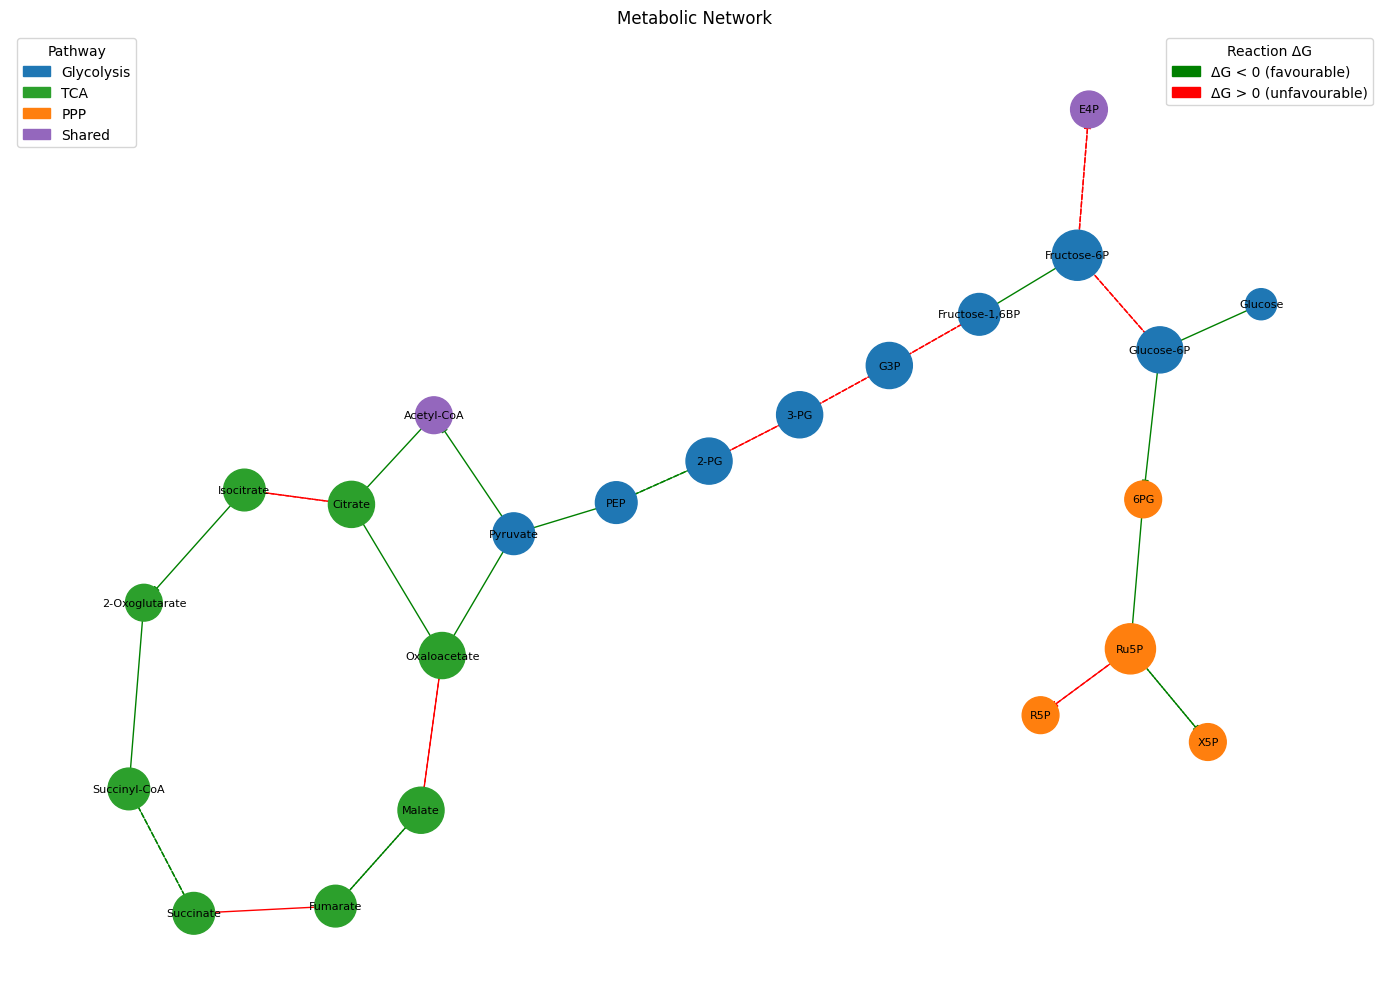

In [22]:
def drawMetabolicNetwork(ax, G, metabolites):

    # Layout
    pos = nx.kamada_kawai_layout(G)

    # Pathway colours
    pathway_colors = {
        "Glycolysis": "tab:blue",
        "TCA": "tab:green",
        "PPP": "tab:orange",
        "Shared": "tab:purple"
    }

    # Node colours
    node_colors = [
        pathway_colors[G.nodes[n]["pathway"]]
        for n in G.nodes()
    ]

    # Degree-scaled node sizes
    node_sizes = [
        300 + 200 * G.degree(n)
        for n in G.nodes()
    ]

    # Labels use metabolite names
    labels = {
        n: G.nodes[n]["name"]
        for n in G.nodes()
    }

    # Separate edges by style and ΔG sign
    solid_edges_neg = []
    solid_edges_pos = []
    dashed_edges_neg = []
    dashed_edges_pos = []

    for u, v, data in G.edges(data=True):

        reversible = data["reversible"]
        favourable = data["delta_G"] < 0

        if reversible:
            if favourable:
                dashed_edges_neg.append((u, v))
            else:
                dashed_edges_pos.append((u, v))
        else:
            if favourable:
                solid_edges_neg.append((u, v))
            else:
                solid_edges_pos.append((u, v))

    # Draw nodes
    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=node_sizes
    )

    # Draw edges
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edgelist=solid_edges_neg,
        edge_color="green",
        style="solid",
        arrows=True
    )

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edgelist=solid_edges_pos,
        edge_color="red",
        style="solid",
        arrows=True
    )

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edgelist=dashed_edges_neg,
        edge_color="green",
        style="dashed",
        arrows=True
    )

    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edgelist=dashed_edges_pos,
        edge_color="red",
        style="dashed",
        arrows=True
    )

    # Labels
    nx.draw_networkx_labels(
        G,
        pos,
        labels=labels,
        ax=ax,
        font_size=8
    )

    # Legends
    pathway_legend = [
        mpatches.Patch(color=color, label=pathway)
        for pathway, color in pathway_colors.items()
    ]

    dg_legend = [
        mpatches.Patch(color="green", label="ΔG < 0 (favourable)"),
        mpatches.Patch(color="red", label="ΔG > 0 (unfavourable)")
    ]

    legend1 = ax.legend(
        handles=pathway_legend,
        title="Pathway",
        loc="upper left"
    )

    ax.add_artist(legend1)

    ax.legend(
        handles=dg_legend,
        title="Reaction ΔG",
        loc="upper right"
    )

    ax.set_title("Metabolic Network")
    ax.axis("off")

#test
fig, ax = plt.subplots(figsize=(14, 10))
drawMetabolicNetwork(ax, G, metabolites)
plt.tight_layout()
plt.savefig('metabolic_network.png', dpi=150)
plt.show()

In [23]:
def centralMetabolites(G, metabolites):
    """
    Returns [(name, centrality)] for the top-5 metabolites by betweenness centrality.
    """

    # Compute betweenness centrality
    bc = nx.betweenness_centrality(G)

    # Sort by descending centrality
    top5 = sorted(
        bc.items(),
        key=lambda x: x[1],
        reverse=True
    )[:5]

    # Convert IDs to metabolite names
    return [
        (metabolites.loc[node_id, "name"], centrality)
        for node_id, centrality in top5
    ]

#test
print("Top-5 central metabolites:")
for name, bc in centralMetabolites(G, metabolites):
    print(f"  {name}: {bc:.4f}")


Top-5 central metabolites:
  Pyruvate: 0.1753
  2-PG: 0.1732
  PEP: 0.1732
  3-PG: 0.1645
  G3P: 0.1472


In [24]:
def findShortestPathway(G, metabolites, source_id, target_id):
    """
    Returns a list of metabolite names along the shortest directed path
    from source_id to target_id, or None if no path exists.
    """

    try:
        path_ids = nx.shortest_path(
            G,
            source=source_id,
            target=target_id
        )

        return [
            metabolites.loc[mid, "name"]
            for mid in path_ids
        ]

    except nx.NetworkXNoPath:
        return None

    except nx.NodeNotFound:
        return None
    
#test
# Test
path = findShortestPathway(G, metabolites, 'C00031', 'C00022')  # Glucose → Pyruvate
print(f"Glucose → Pyruvate: {' → '.join(path) if path else 'No path'}")

Glucose → Pyruvate: Glucose → Glucose-6P → Fructose-6P → Fructose-1,6BP → G3P → 3-PG → 2-PG → PEP → Pyruvate


In [25]:
def pathwayConnectivity(G, metabolites):
    """
    Returns {pathway_pair: n_edges} for edges crossing between pathways.
    Pathway pair is a frozenset of two pathway names (excluding 'Shared').
    """

    connectivity = defaultdict(int)

    for u, v in G.edges():

        source_pathway = metabolites.loc[u, "pathway"]
        target_pathway = metabolites.loc[v, "pathway"]

        # Ignore Shared metabolites
        if source_pathway == "Shared" or target_pathway == "Shared":
            continue

        # Ignore edges within same pathway
        if source_pathway == target_pathway:
            continue

        pair = frozenset(
            [source_pathway, target_pathway]
        )

        connectivity[pair] += 1

    return dict(connectivity)

#test
print("Cross-pathway edges:")
for pair, n in pathwayConnectivity(G, metabolites).items():
    print(f"  {' ↔ '.join(pair)}: {n} edge(s)")


Cross-pathway edges:
  Glycolysis ↔ PPP: 1 edge(s)
  TCA ↔ Glycolysis: 1 edge(s)
